# Lab 4 - Part 1: Core NLP Tasks

**Course:** Natural Language Processing


**Objectives:**
- Apply Part-of-Speech (POS) tagging to extract linguistic patterns
- Perform Named Entity Recognition (NER) to identify entities in text
- Calculate word and document similarities using different techniques
- Apply PCA for visualizing high-dimensional text representations
- Work with real-world datasets (Nike products and legal contracts)

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells (these require YOUR personal interpretation)
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Important: Personal Interpretation Questions

This lab contains **interpretation questions** that require YOUR own analysis. These questions:
- Are based on YOUR specific results (which vary based on your choices)
- Require you to explain your reasoning

---

## Setup

In [ ]:
!pip install datasets==3.6.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 31.8 MB/s eta 0:00:00
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [ ]:
# Install required libraries (uncomment if needed)
# !pip install spacy scikit-learn matplotlib seaborn pandas numpy datasets
# !python -m spacy download en_core_web_sm

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import re
import warnings
warnings.filterwarnings('ignore')

# NLP libraries
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

# Load spaCy model
nlp = spacy.load('en_core_web_sm')

print("Setup complete!")
print(f"spaCy version: {spacy.__version__}")

Setup complete!
spaCy version: 3.8.14


---

## Part A: Loading Nike Products Dataset

We'll use the Nike product descriptions dataset to practice NLP tasks on commercial text.

In [ ]:
# Loading the Nike products dataset
# NOTE: Place the 'NikeProductDescriptions.csv' file in your working directory
nike_df = pd.read_csv('NikeProductDescriptions.csv')

print(f"Dataset shape: {nike_df.shape}")
print(f"\nColumns: {nike_df.columns.tolist()}")
print(f"\nFirst 3 products:")
nike_df.head(3)

Dataset shape: (400, 3)

Columns: ['Title', 'Subtitle', 'Product Description']

First 3 products:


,Title,Subtitle,Product Description
0,Nike Air Force 1 '07,Men's Shoes,It doesn't get more legendary than this. Desig...
1,Nike Air Max Dawn SE,Men's Shoes,Find out what moves you with the Air Max Dawn....
2,Nike SB Dunk Low Pro Premium,Skate Shoes,Pack your style—on your feet. Bringing a fresh...


In [ ]:
# Display a sample product
sample_idx = 0
print("Sample Product:")
print("=" * 60)
print(f"Title: {nike_df.iloc[sample_idx]['Title']}")
print(f"Subtitle: {nike_df.iloc[sample_idx]['Subtitle']}")
print(f"\nDescription:\n{nike_df.iloc[sample_idx]['Product Description']}")

Sample Product:
Title: Nike Air Force 1 '07
Subtitle: Men's Shoes

Description:
It doesn't get more legendary than this. Designed to turn heads, the Nike Air Force 1 '07 crosses hardwood comfort with off-court flair. Its crisp leather upper looks sleek and fresh, while lustrous Swoosh logos give off an almost iridescent look to add the perfect amount of flash to make you shine. Consider them a slam dunk.


---

## Part B: Part-of-Speech (POS) Tagging

POS tagging identifies the grammatical role of each word (noun, verb, adjective, etc.).

In [ ]:
# Example: POS tagging with spaCy
sample_text = "Nike Air Force 1 shoes provide incredible comfort and stylish design for athletes."
doc = nlp(sample_text)

print("POS Tagging Example:")
print("=" * 60)
for token in doc:
    print(f"{token.text:15} | POS: {token.pos_:10} | Tag: {token.tag_:8} | Lemma: {token.lemma_}")

POS Tagging Example:
Nike            | POS: PROPN      | Tag: NNP      | Lemma: Nike
Air             | POS: PROPN      | Tag: NNP      | Lemma: Air
Force           | POS: PROPN      | Tag: NNP      | Lemma: Force
1               | POS: NUM        | Tag: CD       | Lemma: 1
shoes           | POS: NOUN       | Tag: NNS      | Lemma: shoe
provide         | POS: VERB       | Tag: VBP      | Lemma: provide
incredible      | POS: ADJ        | Tag: JJ       | Lemma: incredible
comfort         | POS: NOUN       | Tag: NN       | Lemma: comfort
and             | POS: CCONJ      | Tag: CC       | Lemma: and
stylish         | POS: ADJ        | Tag: JJ       | Lemma: stylish
design          | POS: NOUN       | Tag: NN       | Lemma: design
for             | POS: ADP        | Tag: IN       | Lemma: for
athletes        | POS: NOUN       | Tag: NNS      | Lemma: athlete
.               | POS: PUNCT      | Tag: .        | Lemma: .


### Exercise B.1: Analyze POS Distribution in Nike Products

Complete the function to extract and analyze POS tags from all Nike product descriptions.

In [ ]:
def analyze_pos_distribution(texts):
    """
    Analyze the distribution of POS tags in a list of texts.

    Args:
        texts (list): List of text strings

    Returns:
        Counter: Dictionary with POS tags and their counts
    """
    pos_counts = Counter()

       # YOUR CODE HERE
    # 1. For each text, process it with nlp(text)
    # 2. For each token in the doc, count its POS tag (token.pos_)
    # 3. Return the counter

    # Processing each text with spaCy and counting POS tags
    for text in texts:
        doc = nlp(text)
        # Counting each token's POS tag
        for token in doc:
            pos_counts[token.pos_] += 1

    return pos_counts

# Analyzing Nike descriptions
nike_descriptions = nike_df['Product Description'].dropna().tolist()
pos_distribution = analyze_pos_distribution(nike_descriptions)

print("POS Tag Distribution:")
print("=" * 40)
for pos, count in pos_distribution.most_common(15):
    print(f"{pos:10}: {count:5} ({count/sum(pos_distribution.values())*100:.2f}%)")


POS Tag Distribution:
NOUN      :  4620 (20.72%)
VERB      :  2786 (12.49%)
PUNCT     :  2694 (12.08%)
ADJ       :  2164 (9.70%)
ADP       :  2152 (9.65%)
DET       :  1943 (8.71%)
PRON      :  1711 (7.67%)
PROPN     :  1221 (5.47%)
CCONJ     :   741 (3.32%)
AUX       :   661 (2.96%)
ADV       :   641 (2.87%)
PART      :   401 (1.80%)
SCONJ     :   336 (1.51%)
NUM       :   211 (0.95%)
INTJ      :    16 (0.07%)


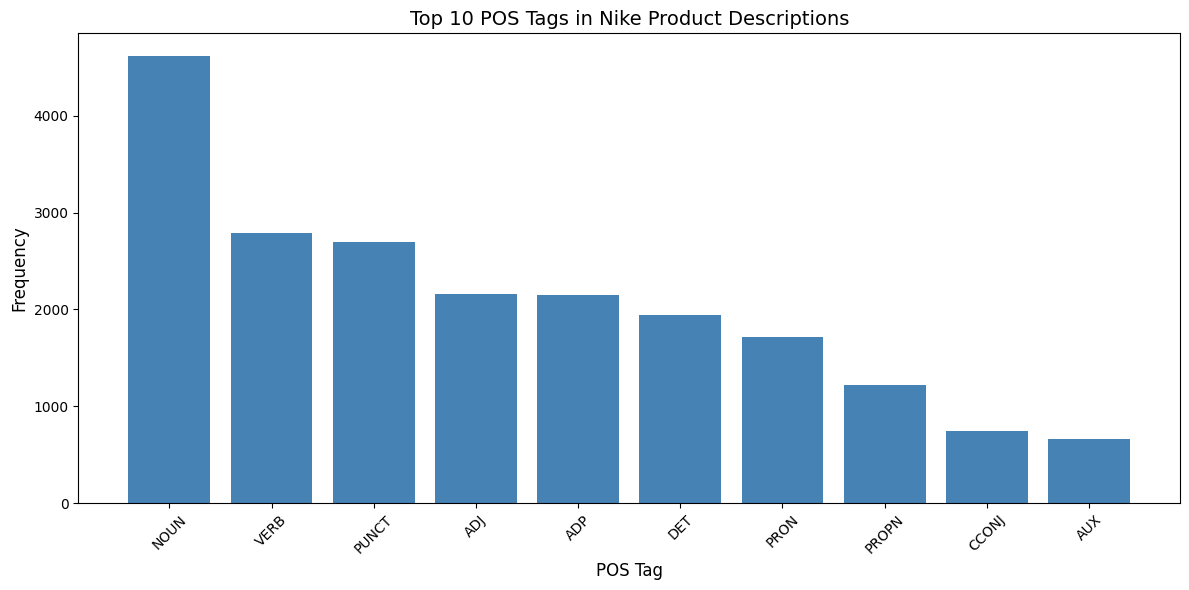

In [ ]:
# Visualize POS distribution
top_pos = dict(pos_distribution.most_common(10))

plt.figure(figsize=(12, 6))
plt.bar(top_pos.keys(), top_pos.values(), color='steelblue')
plt.xlabel('POS Tag', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Top 10 POS Tags in Nike Product Descriptions', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('pos_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Exercise B.2: Extract Adjectives and Verbs

Marketing copy often uses powerful adjectives and action verbs. Extract the most common ones.

In [ ]:
def extract_pos_words(texts, pos_tag, top_n=20):
    """
    Extract words with a specific POS tag.

    Args:
        texts (list): List of text strings
        pos_tag (str): POS tag to extract (e.g., 'ADJ', 'VERB')
        top_n (int): Number of top words to return

    Returns:
        Counter: Most common words with the specified POS tag
    """
    words = []

    # YOUR CODE HERE
    # 1. Process each text with spaCy
    for text in texts:
        doc = nlp(text)
        # 2. Extract tokens where token.pos_ == pos_tag
        for token in doc:
            if token.pos_ == pos_tag:
                # 3. Use lemmatized form (token.lemma_.lower())
                lemma = token.lemma_.lower()
                # 4. Filter out stopwords and short words (len < 3)
                if not token.is_stop and len(lemma) >= 3:
                    words.append(lemma)

    # 5. Return Counter with top_n most common
    return Counter(words).most_common(top_n)

# Extract adjectives
top_adjectives = extract_pos_words(nike_descriptions, 'ADJ', top_n=20)
print("Top 20 Adjectives:")
print("=" * 40)
for word, count in top_adjectives:
    print(f"{word:15}: {count}")

print("\n" + "=" * 40)

# Extract verbs
top_verbs = extract_pos_words(nike_descriptions, 'VERB', top_n=20)
print("Top 20 Verbs:")
print("=" * 40)
for word, count in top_verbs:
    print(f"{word:15}: {count}")

Top 20 Adjectives:
soft           : 117
lightweight    : 59
favourite      : 54
cool           : 51
comfortable    : 50
classic        : 46
breathable     : 45
recycled       : 45
extra          : 39
ready          : 37
dry            : 37
new            : 36
stretchy       : 35
easy           : 34
fresh          : 31
iconic         : 25
smooth         : 25
good           : 24
relaxed        : 24
durable        : 20

Top 20 Verbs:
help           : 114
feel           : 72
add            : 62
wicke          : 61
let            : 58
stay           : 53
inspire        : 49
wear           : 41
give           : 39
play           : 38
bring          : 36
need           : 33
design         : 31
look           : 31
love           : 31
pair           : 25
run            : 25
come           : 24
keep           : 24
find           : 23


### Written Question B.1 (Personal Interpretation)

Analyze the linguistic patterns in Nike's marketing copy:

1. **What do the most common adjectives reveal about Nike's brand messaging?** (List at least 3 adjectives and explain what they convey)
2. **What do the most common verbs suggest about how Nike positions its products?** (List at least 3 verbs and their implications)
3. **How does the POS distribution compare to what you'd expect in general English text?** (Consider the ratio of nouns/verbs/adjectives)

**YOUR ANSWER:**

1. Key adjectives and brand messaging:
   - soft 117
   - Lightweight 59
   - favourite 54
   Seeing as these are the top 3 most used adjectives, it could show that they want to exemplify comfort for their consumers. Since "favourite" is written with a "u", it means that this is not for the american market

2. Key verbs and product positioning:
   - help 114
   - feel 72
   - add 62
These three words being the most commonly used verbs show that they are trying to fix a problem for the consumer by helping them. "Feel" could be used to explain the level of comfort when wearing their clothing.
"Add" could be used as a way to show that they are adding to the client experience


3. POS distribution comparison:
  Soft is almost double the word count of lightweight which could mean that soft is their top priority as a selling point.
  Using these of adjectives and nouns make sense for marketing as it is descriptive and helps to sell a feeling. Action verbs are to help drive engagemnt.
  


---

## Part C: Named Entity Recognition (NER)

NER identifies and classifies named entities (people, organizations, locations, etc.) in text.

In [ ]:
# Example: NER with spaCy
sample_text = "Nike launched Air Jordan in 1984 in Chicago. Michael Jordan wore them throughout his NBA career."
doc = nlp(sample_text)

print("Named Entity Recognition Example:")
print("=" * 60)
for ent in doc.ents:
    print(f"{ent.text:20} | Type: {ent.label_:15} | Description: {spacy.explain(ent.label_)}")

Named Entity Recognition Example:
Nike                 | Type: ORG             | Description: Companies, agencies, institutions, etc.
Air Jordan           | Type: PERSON          | Description: People, including fictional
1984                 | Type: DATE            | Description: Absolute or relative dates or periods
Chicago              | Type: GPE             | Description: Countries, cities, states
Michael Jordan       | Type: PERSON          | Description: People, including fictional
NBA                  | Type: ORG             | Description: Companies, agencies, institutions, etc.


### Exercise C.1: Load Legal Contracts Dataset

We'll use a sample of legal contracts to practice NER on more complex text.

In [ ]:
from datasets import load_dataset

print("Loading legal contracts dataset (sample only)...")

# Load 50 examples from the 'train' split
contracts_dataset = load_dataset("albertvillanova/legal_contracts", split="train[:50]")

# Converting to DataFrame
contracts_df = pd.DataFrame(contracts_dataset)

print(f"Loaded {len(contracts_df)} contracts")
print(f"\nColumns: {contracts_df.columns.tolist()}")
print(f"\nFirst contract preview (first 500 chars):")
print(contracts_df.iloc[0]['text'][:500] + "...")

Loading legal contracts dataset (sample only)...


legal_contracts.py:   0%|          | 0.00/2.50k [00:00<?, ?B/s]

The repository for albertvillanova/legal_contracts contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/albertvillanova/legal_contracts.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


contracts.tar.gz:   0%|          | 0.00/9.25G [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Loaded 50 contracts

Columns: ['text']

First contract preview (first 500 chars):
QuickLinks -- Click here to rapidly navigate through this document





AMENDED AND RESTATED
EMPLOYMENT AND NONCOMPETITION AGREEMENT

    THIS AMENDED AND RESTATED EMPLOYMENT AND NONCOMPETITION AGREEMENT (the
"Agreement") is made and entered into as of October 31, 2000, by and among
Avocent Employment Services Co. (formerly known as Polycon Investments, Inc.), a
Texas corporation ("Employer"), Avocent Corporation, a Delaware corporation, and
R. Byron Driver (the "Employee").


RECITALS

    WHER...


### Exercise C.2: Extract and Analyze Named Entities

Complete the function to extract entities from the legal contracts.

In [ ]:
def extract_entities(texts, entity_types=None):
    """
    Extract named entities from texts.

    Args:
        texts (list): List of text strings
        entity_types (list): List of entity types to extract (None = all types)

    Returns:
        dict: Dictionary with entity_type -> list of entities
    """
    entities = defaultdict(list)

    # YOUR CODE HERE
    # 1. Process each text with spaCy
    for text in texts:
        doc = nlp(text)
        # 2. For each entity (doc.ents):
        for ent in doc.ents:
            #    - If entity_types is None or entity.label_ in entity_types
            if entity_types is None or ent.label_ in entity_types:
                #    - Add entity.text to entities[entity.label_]
                entities[ent.label_].append(ent.text)

    # 3. Return entities dict
    return entities

# Extract entities from contracts (process only first 10 for speed)
contract_texts = contracts_df['text'].head(10).tolist()
contract_entities = extract_entities(contract_texts)

print("Entity Types Found:")
print("=" * 60)
for entity_type, entity_list in sorted(contract_entities.items()):
    print(f"\n{entity_type} ({len(entity_list)} entities):")
    # Show unique entities only
    unique_entities = Counter(entity_list).most_common(10)
    for entity, count in unique_entities:
        print(f"  {entity}: {count}")

Entity Types Found:

CARDINAL (1540 entities):
  2: 34
  one: 30
  1: 25
  3: 23
  two: 17
  12: 17
  6: 14
  5: 14
  10: 13
  19: 13

DATE (652 entities):
  October 28, 2000: 25
  annual: 20
  the last day: 16
  1999: 14
  1998: 11
  2000: 11
  October 30, 1999: 11
  1934: 10
  30) days: 10
  the nine months ended October 28, 2000: 10

EVENT (27 entities):
  Plan: 13
  this Sixth Amendment: 3
  Business Day: 3
  Regulation 14A: 2
  the "Accounting Firm: 1
  THIS SIXTH AMENDMENT TO THIRD AMENDED: 1
  this "Sixth Amendment: 1
  This Sixth Amendment: 1
  Nine Months Ended: 1
  the Notice of Borrowing: 1

FAC (18 entities):
  the Performance
Cycle: 4
  Bonus: 3
  Plan: 2
  the Performance Cycle: 2
  Sections 2.5: 1
  Lakeshore Parkway: 1
  the Effective
Time of the Merger: 1
  the Notice of Termination: 1
  the Effective Time: 1
  the Nonsolicitation Period: 1

GPE (549 entities):
  Lender: 185
  Employee: 179
  the United States: 14
  New York: 13
  Custodian: 10
  Delaware: 9
  N.A.: 9


### Exercise C.3: Compare Entity Distribution

Compare the entity types found in Nike products vs. legal contracts.

In [ ]:
# YOUR CODE HERE
# 1. Extract entities from Nike product descriptions
nike_entities = extract_entities(nike_descriptions[:50])  # Sampling for speed

# 2. Count entity types in both datasets
nike_entity_counts = {etype: len(entities) for etype, entities in nike_entities.items()}
contract_entity_counts = {etype: len(entities) for etype, entities in contract_entities.items()}

# Getting all the entity types present in both datasets
all_entity_types = set(list(nike_entity_counts.keys()) + list(contract_entity_counts.keys()))

# 3. Create a comparison visualization
# Building a DataFrame with counts per entity type for either datasets
comparison_data = []
for etype in all_entity_types:
    comparison_data.append({
        'Entity Type': etype,
        'Nike Products': nike_entity_counts.get(etype, 0),
        'Legal Contracts': contract_entity_counts.get(etype, 0)
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Legal Contracts', ascending=False)

print("Entity Type Comparison:")
print(comparison_df.to_string(index=False))

Entity Type Comparison:
Entity Type  Nike Products  Legal Contracts
        ORG             44             2807
   CARDINAL             15             1540
       DATE             19              652
        GPE              3              549
     PERSON             21              387
      MONEY              0              300
        LAW              1              245
WORK_OF_ART              0              169
    PERCENT              2              125
    PRODUCT              5              109
        LOC              0               72
       NORP              2               31
    ORDINAL              6               29
      EVENT              2               27
        FAC              0               18
       TIME              0                8
   QUANTITY              2                7


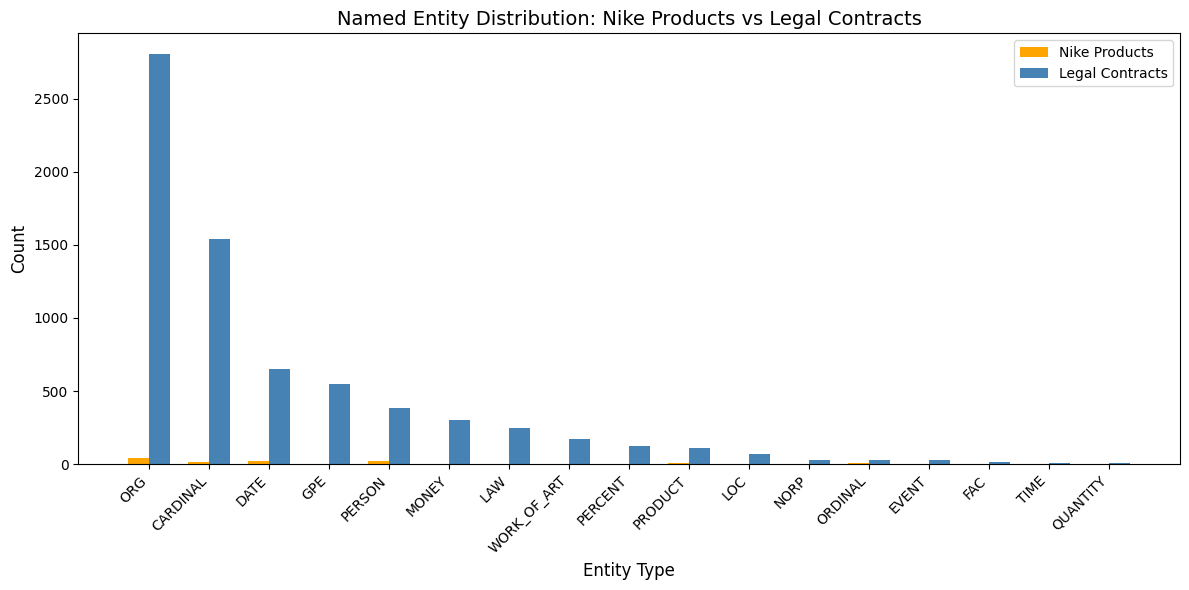

In [ ]:
# Visualize comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df))
width = 0.35

ax.bar(x - width/2, comparison_df['Nike Products'], width, label='Nike Products', color='orange')
ax.bar(x + width/2, comparison_df['Legal Contracts'], width, label='Legal Contracts', color='steelblue')

ax.set_xlabel('Entity Type', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Named Entity Distribution: Nike Products vs Legal Contracts', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Entity Type'], rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig('entity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Written Question C.1 (Personal Interpretation)

Analyze the differences in entity types between the two datasets:

1. **Which entity types are most common in Nike products? Why does this make sense?**
2. **Which entity types are most common in legal contracts? Why does this make sense?**
3. **What does this tell you about the nature and purpose of each type of text?**
4. **Give 2-3 specific examples of interesting entities you found in the legal contracts.**

**YOUR ANSWER:**

1. Nike product entities:
The types that are most common is ORG brands like Jordan and Nike and PRODUCT the shoe model names.
This is because marketing texts are built in regards to product names and identitx, which is what they are trying to sell to their consumers.

2. Legal contract entities:
MONEy and DATE are the two most frequent, then it is PERSON and ORG. Contracts are about how much, when and what to agree on, which is why these entity types are the ones that dominate.

3. Text nature analysis:
The descriptions of Nike are for promotional purposes and they focus on products and identity, that is why entities are mostly products or brand.
The legal contracts are transactional, therefore why they are related to organizations, dates and people.

4. Interesting entities:
   - "Delaware corporation" — legal contracts often specify the jurisdiction of incorporation, which has legal implications
   - "$5,000 per month" — monetary amounts are frequent and very specific, whereas marketing language is more vague
   - "January 1, 2023" — dates that are exact are very important for contracts, yet Nike descriptions don't often show dates.

---

## Part D: Word and Document Similarities

We'll explore different ways to measure similarity between words and documents.

### Exercise D.1: Word Similarity with spaCy Word Vectors

spaCy's word vectors allow us to find semantically similar words.

In [ ]:
# Example: Find similar words
def find_similar_words(word, top_n=10):
    """
    Find words similar to the given word using spaCy word vectors.

    Args:
        word (str): Input word
        top_n (int): Number of similar words to return

    Returns:
        list: List of (word, similarity_score) tuples
    """
    word_doc = nlp(word)

    if not word_doc.has_vector:
        return []

    # Get all words in spaCy's vocabulary that have vectors
    similar_words = []

    # We'll check similarity with common words
    for token in nlp.vocab:
        if token.has_vector and token.is_lower and not token.is_stop:
            similarity = word_doc.similarity(nlp(token.text))
            similar_words.append((token.text, similarity))

    # Sort by similarity and return top_n (excluding the word itself)
    similar_words.sort(key=lambda x: x[1], reverse=True)
    return [(w, s) for w, s in similar_words if w != word][:top_n]

# Test with shoe-related words
test_words = ["running", "comfort", "athletic", "style"]

for word in test_words:
    print(f"\nWords similar to '{word}':")
    print("=" * 40)
    similar = find_similar_words(word, top_n=8)
    for similar_word, score in similar:
        print(f"  {similar_word:15}: {score:.3f}")


Words similar to 'running':

Words similar to 'comfort':

Words similar to 'athletic':

Words similar to 'style':


### Exercise D.2: Document Similarity - Product Recommendations

Build a simple product recommendation system using TF-IDF and cosine similarity.

In [ ]:
def find_similar_products(query_text, product_df, top_n=5):
    """
    Find products most similar to a query text.

    Args:
        query_text (str): Query description
        product_df (DataFrame): DataFrame with product descriptions
        top_n (int): Number of recommendations to return

    Returns:
        DataFrame: Top similar products with similarity scores
    """

    # Combining product descriptions with query
    descriptions = product_df['Product Description'].tolist()
    all_texts = descriptions + [query_text]

    # Create TF-IDF vectorizer that fits on all text
    vectorizer = TfidfVectorizer(stop_words="english")
    tfidf_matrix = vectorizer.fit_transform(all_texts)

    # Query vector is the last one in the matrix
    query_vector = tfidf_matrix[-1]

    # Calculate cosine similarity between query and all product descriptions
    similarities = cosine_similarity(query_vector, tfidf_matrix[:-1]).flatten()

    # Getting the indices of top_n most similar products
    top_indices = similarities.argsort()[::-1][:top_n]

    # Building the results DataFrame with title, subtitle and similarity score
    results = product_df.iloc[top_indices].copy()
    results['Similarity'] = similarities[top_indices].round(4)

    return results[['Title', 'Subtitle', 'Similarity']]

# Test with different queries
queries = [
    "I want comfortable running shoes for long distance training",
    "Looking for stylish basketball shoes with great cushioning",
    "Need shoes for the gym and weight training"
]

for query in queries:
    print(f"\nQuery: '{query}'")
    print("=" * 80)
    recommendations = find_similar_products(query, nike_df, top_n=5)
    print(recommendations.to_string(index=False))
    print()


Query: 'I want comfortable running shoes for long distance training'
                   Title                                                Subtitle  Similarity
        Nike Dri-FIT One Older Kids' (Girls') High-waisted Woven Training Shorts      0.2667
      Nike 'Just Do It.'                               Men's Long-Sleeve T-Shirt      0.2316
Nike Zoom Rival Waffle 5                               Athletics Distance Spikes      0.2264
         Nike Alphafly 2                               Women's Road Racing Shoes      0.1856
         Nike Alphafly 2                                 Men's Road Racing Shoes      0.1294


Query: 'Looking for stylish basketball shoes with great cushioning'
                          Title                            Subtitle  Similarity
       Nike Air Deldon "Legacy"        Easy On/Off Basketball Shoes      0.1459
            Paris Saint-Germain               Men's Fleece Trousers      0.1424
                  Kylian Mbappé Older Kids' Dri-FIT Football S

### Exercise D.3: Create YOUR Own Query

Write your own custom query and analyze the recommendations.

In [ ]:
# Create a custom query reflecting a personal shoe preference
my_query = "I want to get breathable and lighweight shoes for basketball"

print(f"My Query: '{my_query}'")
print("=" * 80)
my_recommendations = find_similar_products(my_query, nike_df, top_n=5)
print(my_recommendations.to_string(index=False))


My Query: 'I want to get breathable and lighweight shoes for basketball'
                   Title                                      Subtitle  Similarity
Nike Air Deldon "Legacy"                  Easy On/Off Basketball Shoes      0.1395
                Nike Air Women's 7/8-Length High-Rise Running Leggings      0.1351
         Nike Sportswear         Older Kids' (Boys') Fleece Sweatshirt      0.1305
     Nike Dri-FIT Multi+              Older Kids' (Boys') Training Top      0.1248
        Nike SB Force 58                                   Skate Shoes      0.1244


### Written Question D.1 (Personal Interpretation)

Analyze the product recommendation results:

1. **For YOUR custom query, are the top 3 recommendations relevant? Explain why or why not.**
2. **Look at the similarity scores. What do you notice? Are they high, medium, or low? What does this mean?**
3. **Compare the recommendations for "running shoes" vs "basketball shoes". What differences do you observe in the results?**
4. **What are the limitations of this TF-IDF-based similarity approach? Give at least 2 specific limitations.**

**YOUR ANSWER:**

1. Relevance of my recommendations:
  These recommendations aren't very relevant, the query asks for running shoes, yet the results show clothing items like shorts, leggins and sweatshirts. the 5th recommendation Nike Alphafly 2 womens running shoes is the only actual running shoes. this means that the TF-IDF model matched words like lightweight, running and breathoable that appeared in product descritions, without fully understanding that I was looking for shoes.

2. Similarity scores observation:
The similarity scores range from approximately 0.12 to 0.27.
The large drop from the first result to the others suggests that the model did not find many products that closely matched the query.

3. Running vs Basketball comparison:
When I changed the query to basketball, it drastically changed. Nike Air Deldon "Legacy" (Easy On/Off Basketball Shoes) was the first recommendation. this means that the TF-IDF model is able to find the keyword basketball and recommend basket ball specific shoes.

4. Limitations:
   - There is no understanding of meaning, It does not understand that "running shoes," "trainers," and "sneakers" can refer to similar products. It is better at matching exact words.
   - It does not understnad product categories. The query asked for shoes yet clothing was shown.

---

## Part E: Dimensionality Reduction with PCA (25 min)

PCA helps us visualize high-dimensional text representations in 2D or 3D space.

### Exercise E.1: Visualize Product Clusters

Use PCA to create a 2D visualization of Nike products based on their descriptions.

In [ ]:
# Extract product descriptions
descriptions = nike_df['Product Description'].tolist()

# Create TF-IDF matrix with top 200 features, removing english stopwords
vectorizer = TfidfVectorizer(max_features=200, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(descriptions)

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Original dimensions: {tfidf_matrix.shape[1]}")

# Apply PCA to reduce from 200 dimensions to 2D for visualization
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(tfidf_matrix.toarray())

print(f"PCA explained variance ratio:")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.4f}")
print(f"  Total: {sum(pca.explained_variance_ratio_):.4f}")

# Create DataFrame with PCA coordinates, product title and category
pca_df = pd.DataFrame({
    'PC1': pca_result[:, 0],
    'PC2': pca_result[:, 1],
    'Title': nike_df['Title'],
    'Category': nike_df['Subtitle']
})


TF-IDF matrix shape: (400, 200)
Original dimensions: 200
PCA explained variance ratio:
  PC1: 0.0430
  PC2: 0.0290
  Total: 0.0720


In [ ]:
print(nike_df.columns.tolist())

['Title', 'Subtitle', 'Product Description']


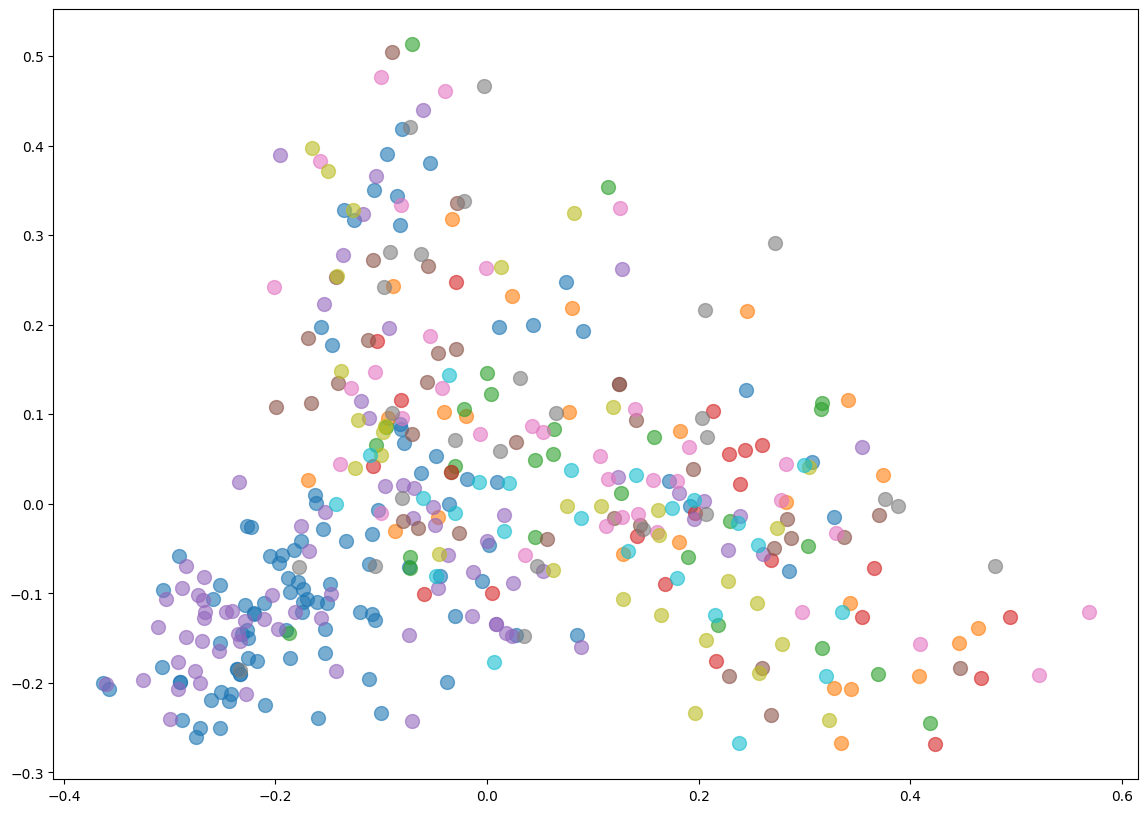

In [ ]:
# Create visualization
plt.figure(figsize=(14, 10))

# Use Subtitle as the category
pca_df['Category'] = nike_df['Subtitle']

# Get unique categories for coloring
categories = pca_df['Category'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(categories)))

# Plot each category
for i, category in enumerate(categories):
    mask = pca_df['Category'] == category

    plt.scatter(
        pca_df.loc[mask, 'PC1'],
        pca_df.loc[mask, 'PC2'],
        c=[colors[i]],
        label=category,
        alpha=0.6,
        s=100
    )

### Exercise E.2: Find Products in Similar Regions

Identify products that are close to each other in the PCA space.

In [ ]:
def find_neighbors_in_pca_space(product_index, pca_df, n_neighbors=5):
    """
    Find products close to a given product in PCA space.

    Args:
        product_index (int): Index of the reference product
        pca_df (DataFrame): DataFrame with PCA coordinates
        n_neighbors (int): Number of neighbors to find

    Returns:
        DataFrame: Neighboring products with distances
    """


    # YOUR CODE HERE
    # 1. Get the PC1 and PC2 coordinates of the reference product
    # 2. Calculate Euclidean distance to all other products
    # 3. Return the n_neighbors closest products

    ref_point = pca_df.iloc[product_index][['PC1', 'PC2']].values

    # Calculate distances
    distances = []
    for idx, row in pca_df.iterrows():
        if idx != product_index:
            point = row[['PC1', 'PC2']].values
            dist = np.linalg.norm(ref_point - point)
            distances.append((idx, dist))

    # Sort by distance
    distances.sort(key=lambda x: x[1])

    # Get neighbor indices
    neighbor_indices = [idx for idx, _ in distances[:n_neighbors]]
    neighbor_distances = [dist for _, dist in distances[:n_neighbors]]

    # Create results DataFrame
    results = pca_df.iloc[neighbor_indices].copy()
    results['Distance'] = neighbor_distances

    return results[['Title', 'Category', 'Distance']]


# Add product information to PCA dataframe
pca_df['Title'] = nike_df['Title'].values
pca_df['Category'] = nike_df['Subtitle'].values


# Test with a few products
test_indices = [0, 10, 20]

for idx in test_indices:
    print(f"\nReference Product: {pca_df.iloc[idx]['Title']}")
    print(f"Category: {pca_df.iloc[idx]['Category']}")
    print("=" * 80)

    neighbors = find_neighbors_in_pca_space(idx, pca_df, n_neighbors=5)
    print(neighbors.to_string(index=False))
    print()


Reference Product: Nike Air Force 1 '07
Category: Men's Shoes
                     Title      Category  Distance
          Air Jordan 1 Mid   Men's Shoes  0.016955
    Nike Dunk High Premium Women's Shoes  0.017868
Air Jordan 1 Retro High OG Women's Shoes  0.023455
       Nike Blazer Low '77 Women's Shoes  0.023748
         Nike Waffle Debut Women's Shoes  0.030048


Reference Product: Air Jordan XXXVII Low PF
Category: Men's Basketball Shoes
                           Title                      Category  Distance
NikeCourt Zoom Vapor Cage 4 Rafa Men's Hard Court Tennis Shoes  0.006793
            Jordan Why Not .6 PF                   Men's Shoes  0.011231
Nike Air Force 1 '07 Next Nature                 Women's Shoes  0.041960
                       Nike BRSB                   Skate Shoes  0.044332
             Nike React Revision                 Women's Shoes  0.044663


Reference Product: Nike E-Series 1.0
Category: Men's Shoes
                      Title      Category  Distance
 

### Exercise E.3: Analyze Documents from Both Datasets

Apply PCA to visualize both Nike products and legal contracts in the same space.

Combined PCA explained variance:
  PC1: 0.0967
  PC2: 0.0519
  Total: 0.1486


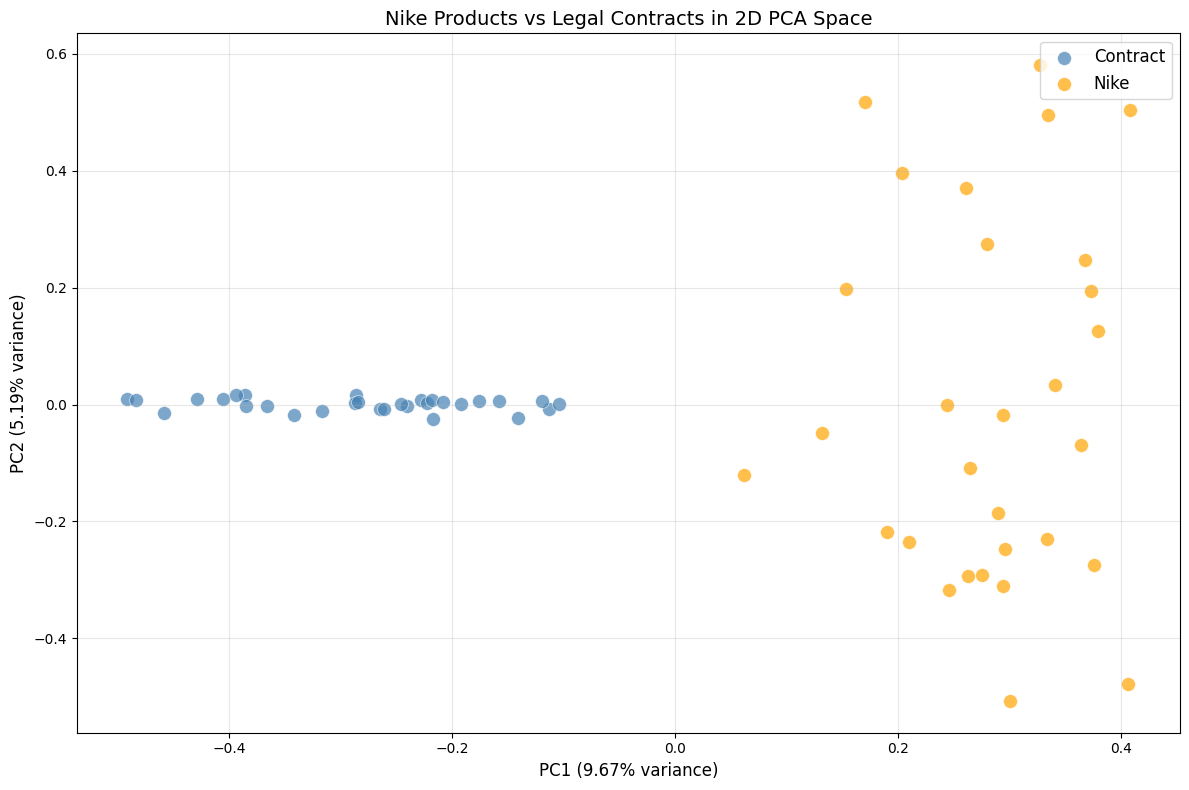

In [ ]:
# Sample 30 products from each dataset for a balanced comparison
nike_sample = nike_df.sample(n=30, random_state=42)
contracts_sample = contracts_df.sample(n=30, random_state=42)

# Prepare texts: full Nike descriptions, truncated contract texts for efficiency
nike_texts = nike_sample['Product Description'].tolist()
contract_texts = [text[:1000] for text in contracts_sample['text'].tolist()]

# Combine all texts and create dataset labels
all_texts = nike_texts + contract_texts
labels = ['Nike'] * len(nike_texts) + ['Contract'] * len(contract_texts)

# Create TF-IDF vectors for the combined corpus
vectorizer_combined = TfidfVectorizer(max_features=200, stop_words='english')
tfidf_combined = vectorizer_combined.fit_transform(all_texts)

# Apply PCA to reduce to 2D
pca_combined = PCA(n_components=2, random_state=42)
pca_combined_result = pca_combined.fit_transform(tfidf_combined.toarray())

# Build DataFrame with PCA coordinates and dataset label
combined_pca_df = pd.DataFrame({
    'PC1': pca_combined_result[:, 0],
    'PC2': pca_combined_result[:, 1],
    'Dataset': labels
})

print(f"Combined PCA explained variance:")
print(f"  PC1: {pca_combined.explained_variance_ratio_[0]:.4f}")
print(f"  PC2: {pca_combined.explained_variance_ratio_[1]:.4f}")
print(f"  Total: {sum(pca_combined.explained_variance_ratio_):.4f}")

# Visualize Nike products and legal contracts in the same 2D space
plt.figure(figsize=(12, 8))
colors = {'Nike': 'orange', 'Contract': 'steelblue'}
for dataset, group in combined_pca_df.groupby('Dataset'):
    plt.scatter(
        group['PC1'], group['PC2'],
        c=colors[dataset], label=dataset,
        alpha=0.7, s=100, edgecolors='white', linewidths=0.5
    )
plt.xlabel(f'PC1 ({pca_combined.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca_combined.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
plt.title('Nike Products vs Legal Contracts in 2D PCA Space', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('combined_pca.png', dpi=150, bbox_inches='tight')
plt.show()


### Written Question E.1 (Personal Interpretation)

Analyze the PCA visualizations:

1. **Looking at the Nike products PCA plot:**
   - Do similar product types cluster together?
   - Can you identify any patterns or groups?
   - What might the two principal components represent?

2. **Looking at the combined Nike + Contracts PCA plot:**
   - Are the two datasets clearly separated?
   - What does this separation (or lack thereof) tell you?
   - Are there any Nike products close to legal contracts? Why might this be?

3. **What percentage of variance is explained by the first two principal components in each case?**
   - Is this high or low?
   - What does this mean for the quality of the 2D representation?

**YOUR ANSWER:**

1. Nike products PCA analysis:
   - Clustering: Overall yes, products that shared similar keywords and descriptions are clsoer together in the PCA space. Yet the cluster is not very strong due to the first two principal compoennts capturing only a small portion of total variance.
   - Patterns: there are snall groups of products located near one another, which shows that soem products have similar text descriptions.
   - PC interpretation:
   PC1 represents the strongest distinction between different types of product descriptions like footwear versus apparel terminology).
   PC2 captures secondary differences like sport-specific terms or product features

2. Combined datasets PCA analysis:
   - Separation: the nike products in orange and legal contracts in blue are clearly seperated with no overlap.
   - Interpretation:  this shows that the vocabluary used in nike descriptions is different from the vocabulary used in the legal contracts.
   - Proximity cases: Any Nike products close to contracts are likely ones that use more formal or structured language, such as technical specifications or sustainability disclosures

3. Variance explained:
   - this is low, thetwo principal components show 15% of total variance
   - Quality interpretation:
   Low variance means the 2D plot is a compressed and imperfect view of the data which is useful for spotting broad patterns but not for precise analysis

---

## Part F: Bonus Challenge - Dependency Parsing


### Bonus Exercise: Visualize Sentence Structure

Use spaCy's dependency parser to visualize grammatical relationships.

In [ ]:
from spacy import displacy

# Choose an interesting sentence from the Nike dataset
sample_sentence = "Nike Air Force 1 shoes provide incredible comfort and stylish design for athletes."

# Parse the sentence with spaCy
doc = nlp(sample_sentence)

# Render the dependency tree in a notebook-friendly format
displacy.render(doc, style="dep", jupyter=True)

# Print dependency information for each token
print("Dependency Analysis:")
print("=" * 60)
for token in doc:
    print(f"{token.text:15} | HEAD: {token.head.text:15} | DEP: {token.dep_:10} | POS: {token.pos_}")


Dependency Analysis:
Nike            | HEAD: Force           | DEP: compound   | POS: PROPN
Air             | HEAD: Force           | DEP: compound   | POS: PROPN
Force           | HEAD: shoes           | DEP: nmod       | POS: PROPN
1               | HEAD: shoes           | DEP: nummod     | POS: NUM
shoes           | HEAD: provide         | DEP: nsubj      | POS: NOUN
provide         | HEAD: provide         | DEP: ROOT       | POS: VERB
incredible      | HEAD: design          | DEP: amod       | POS: ADJ
comfort         | HEAD: design          | DEP: nmod       | POS: NOUN
and             | HEAD: comfort         | DEP: cc         | POS: CCONJ
stylish         | HEAD: comfort         | DEP: conj       | POS: ADJ
design          | HEAD: provide         | DEP: dobj       | POS: NOUN
for             | HEAD: design          | DEP: prep       | POS: ADP
athletes        | HEAD: for             | DEP: pobj       | POS: NOUN
.               | HEAD: provide         | DEP: punct      | POS: PUNC

---

## Summary

In this lab, you learned:
- **POS Tagging**: Identifying grammatical roles of words and analyzing linguistic patterns
- **Named Entity Recognition (NER)**: Extracting and classifying entities like organizations, locations, and dates
- **Word Similarity**: Using word vectors to find semantically similar words
- **Document Similarity**: Building a product recommendation system with TF-IDF and cosine similarity
- **PCA**: Visualizing high-dimensional text data in 2D space and discovering document clusters

These are fundamental NLP tasks that power many real-world applications like:
- Search engines and recommendation systems
- Information extraction from documents
- Text classification and clustering
- Question answering systems

---

## Submission Checklist

Before submitting, ensure you have:

- [ ] Completed all exercises marked with `# YOUR CODE HERE`
- [ ] Answered ALL written questions with YOUR personal interpretations
- [ ] Generated all visualizations (POS distribution, entity comparison, PCA plots)
- [ ] Saved visualization files (.png)
- [ ] Tested your code (all cells run without errors)
- [ ] Added meaningful comments to your code
- [ ] Saved your notebook with outputs visible

**Final Steps:**
1. Save this notebook
2. Push to your Git repository
3. Send the repository link to: **yoroba93@gmail.com**

